# 07 — Feature Group Comparison

## Objective

Determine which groups of information provide incremental value for
15-minute-ahead industrial energy forecasting.

Notebook 06 identified XGBoost and Random Forest as the two strongest
candidate model families.

This notebook keeps:

- the same forecasting target;
- the same expanding-window validation folds;
- the same evaluation metrics;
- the same default model configurations.

Only the available feature groups are changed.

Feature sets:

A. Historical energy only  
B. Historical energy + calendar information  
C. Historical energy + calendar + load type  

The December 2018 test period remains untouched.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

In [23]:
#Load gold table
con = duckdb.connect("Steel_energy.duckdb")

df = con.sql("""
SELECT *
FROM gold_energy_features
ORDER BY timestamp
""").df()

df = df.sort_values(
    "timestamp"
).reset_index(drop=True)

df.head()

,timestamp,usage_kwh,hour,month,day_of_week,week_status,load_type,usage_15min_ago,usage_1h_ago,usage_lag_96,avg_usage_previous_hour
0,2018-01-01 00:00:00,3.42,0,1,Monday,Weekday,Light_Load,NaN,NaN,NaN,NaN
1,2018-01-01 00:15:00,3.17,0,1,Monday,Weekday,Light_Load,3.42,NaN,NaN,3.4200
2,2018-01-01 00:30:00,4.00,0,1,Monday,Weekday,Light_Load,3.17,NaN,NaN,3.2950
3,2018-01-01 00:45:00,3.24,0,1,Monday,Weekday,Light_Load,4.00,NaN,NaN,3.5300
4,2018-01-01 01:00:00,3.31,1,1,Monday,Weekday,Light_Load,3.24,3.42,NaN,3.4575


In [24]:
#Inspect schema
df.columns.tolist()

['timestamp',
 'usage_kwh',
 'hour',
 'month',
 'day_of_week',
 'week_status',
 'load_type',
 'usage_15min_ago',
 'usage_1h_ago',
 'usage_lag_96',
 'avg_usage_previous_hour']

In [26]:
#Define feature groups
historical_features = [
    "usage_15min_ago",
    "usage_1h_ago",
    "usage_lag_96",
    "avg_usage_previous_hour"
]

calendar_numeric = [
    "hour",
    "month"
]

calendar_categorical = [
    "day_of_week",
    "week_status"
]

operational_features = [
    "load_type"
]

In [28]:
#Define the experiment
feature_groups = {

    "A_History": {
        "numeric": historical_features,
        "categorical": []
    },

    "B_History_Calendar": {
        "numeric": (
            historical_features
            +
            calendar_numeric
        ),
        "categorical": calendar_categorical
    },

    "C_History_Calendar_Load": {
        "numeric": (
            historical_features
            +
            calendar_numeric
        ),
        "categorical": (
            calendar_categorical
            +
            operational_features
        )
    }
}

In [29]:
#Define target
target = "usage_kwh"

In [30]:
#Handle NULL values
required_history = historical_features + [target]

model_df = df.dropna(
    subset=required_history
).copy()

df.shape, model_df.shape

((35040, 11), (34944, 11))

In [31]:
#Metrics
def evaluate_forecast(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [32]:
#Walk forward folds
folds = [
    ("2018-05-01", "2018-06-01"),
    ("2018-06-01", "2018-07-01"),
    ("2018-07-01", "2018-08-01"),
    ("2018-08-01", "2018-09-01"),
    ("2018-09-01", "2018-10-01"),
    ("2018-10-01", "2018-11-01"),
    ("2018-11-01", "2018-12-01"),
]

In [33]:
#Model families
base_models = {

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
}

In [34]:
#Pipeline definition
#we need a function. categorical columns change between groups
#preprocessor for each experiment needed
def build_pipeline(
    numeric_features,
    categorical_features,
    estimator
):

    transformers = []

    if numeric_features:
        transformers.append(
            (
                "num",
                "passthrough",
                numeric_features
            )
        )

    if categorical_features:
        transformers.append(
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                categorical_features
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers
    )

    pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            estimator
        )
    ])

    return pipeline

In [35]:
#Run the ablation experiment
results = []

for group_name, group_info in feature_groups.items():

    numeric_features = group_info["numeric"]
    categorical_features = group_info["categorical"]

    feature_columns = (
        numeric_features
        +
        categorical_features
    )

    for fold_number, (
        val_start,
        val_end
    ) in enumerate(
        folds,
        start=1
    ):

        train = model_df[
            model_df["timestamp"] < val_start
        ].copy()

        val = model_df[
            (
                model_df["timestamp"] >= val_start
            )
            &
            (
                model_df["timestamp"] < val_end
            )
        ].copy()


        X_train = train[
            feature_columns
        ]

        y_train = train[
            target
        ]

        X_val = val[
            feature_columns
        ]

        y_val = val[
            target
        ]


        for model_name, estimator in base_models.items():

            pipeline = build_pipeline(
                numeric_features,
                categorical_features,
                clone(estimator)
            )

            pipeline.fit(
                X_train,
                y_train
            )

            predictions = pipeline.predict(
                X_val
            )

            metrics = evaluate_forecast(
                y_val,
                predictions
            )

            results.append({
                "fold": fold_number,
                "validation_month": val_start,
                "feature_group": group_name,
                "model": model_name,
                "n_features_raw": len(feature_columns),
                **metrics
            })

In [36]:
#Results dataframe
results_df = pd.DataFrame(
    results
)

results_df.head(20)

,fold,validation_month,feature_group,model,n_features_raw,MAE,RMSE,R2
0,1,2018-05-01,A_History,Random Forest,4,6.264802,13.377106,0.844566
1,1,2018-05-01,A_History,XGBoost,4,6.664531,14.241036,0.823841
2,2,2018-06-01,A_History,Random Forest,4,5.855068,12.115563,0.829492
3,2,2018-06-01,A_History,XGBoost,4,6.029654,12.614556,0.815158
4,3,2018-07-01,A_History,Random Forest,4,5.483164,10.963438,0.877174
5,3,2018-07-01,A_History,XGBoost,4,5.522483,11.031802,0.875637
6,4,2018-08-01,A_History,Random Forest,4,5.004418,10.948981,0.877545
7,4,2018-08-01,A_History,XGBoost,4,5.152115,11.121523,0.873656
8,5,2018-09-01,A_History,Random Forest,4,4.643240,10.325337,0.865791
9,5,2018-09-01,A_History,XGBoost,4,4.669224,10.370430,0.864616


In [37]:
#Summary table
feature_summary = (
    results_df
    .groupby(
        [
            "model",
            "feature_group"
        ]
    )
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        R2_mean=("R2", "mean"),
        R2_std=("R2", "std")
    )
    .reset_index()
    .sort_values(
        "MAE_mean"
    )
)

feature_summary

,model,feature_group,MAE_mean,MAE_std,RMSE_mean,R2_mean,R2_std
5,XGBoost,C_History_Calendar_Load,5.059619,0.641519,10.429373,0.891210,0.011223
2,Random Forest,C_History_Calendar_Load,5.088596,0.719545,10.450835,0.890917,0.012753
1,Random Forest,B_History_Calendar,5.166736,0.710770,10.631126,0.887015,0.013529
4,XGBoost,B_History_Calendar,5.221242,0.653151,10.672854,0.886014,0.014933
0,Random Forest,A_History,5.704398,0.686120,11.813429,0.860078,0.018602
3,XGBoost,A_History,5.837726,0.744840,12.095830,0.853011,0.025671


In [39]:
#Comparison table
mae_comparison = feature_summary.pivot(
    index="feature_group",
    columns="model",
    values="MAE_mean"
)

mae_comparison

model,Random Forest,XGBoost
feature_group,,
A_History,5.704398,5.837726
B_History_Calendar,5.166736,5.221242
C_History_Calendar_Load,5.088596,5.059619


In [40]:
#Incremental changes
xgb_results = (
    feature_summary[
        feature_summary["model"]
        ==
        "XGBoost"
    ]
    .set_index(
        "feature_group"
    )
)

xgb_results

,model,MAE_mean,MAE_std,RMSE_mean,R2_mean,R2_std
feature_group,,,,,,
C_History_Calendar_Load,XGBoost,5.059619,0.641519,10.429373,0.891210,0.011223
B_History_Calendar,XGBoost,5.221242,0.653151,10.672854,0.886014,0.014933
A_History,XGBoost,5.837726,0.744840,12.095830,0.853011,0.025671


In [42]:
history_mae = xgb_results.loc[
    "A_History",
    "MAE_mean"
]

calendar_mae = xgb_results.loc[
    "B_History_Calendar",
    "MAE_mean"
]

load_mae = xgb_results.loc[
    "C_History_Calendar_Load",
    "MAE_mean"
]

In [43]:
#Calendar improvement
calendar_improvement_pct = (
    (
        history_mae
        -
        calendar_mae
    )
    /
    history_mae
    *
    100
)

calendar_improvement_pct

np.float64(10.560335229122938)

In [44]:
#Load type incremental improvement
load_improvement_pct = (
    (
        calendar_mae
        -
        load_mae
    )
    /
    calendar_mae
    *
    100
)

load_improvement_pct

np.float64(3.0954921629316425)

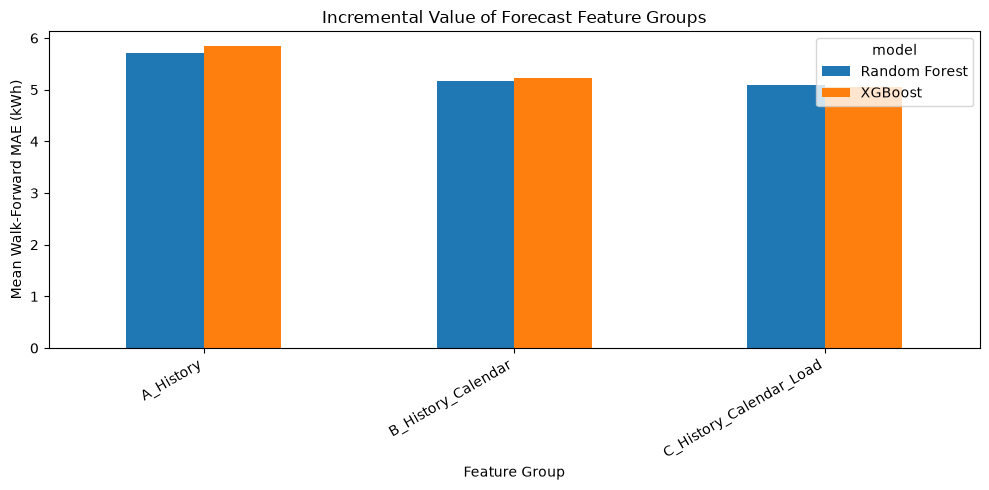

In [45]:
#Plot feature group performance
mae_comparison.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel(
    "Mean Walk-Forward MAE (kWh)"
)

plt.xlabel(
    "Feature Group"
)

plt.title(
    "Incremental Value of Forecast Feature Groups"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()

In [46]:
#Compare through time
xgb_monthly = (
    results_df[
        results_df["model"] == "XGBoost"
    ]
    .pivot(
        index="validation_month",
        columns="feature_group",
        values="MAE"
    )
)

xgb_monthly

feature_group,A_History,B_History_Calendar,C_History_Calendar_Load
validation_month,,,
2018-05-01,6.664531,5.853376,5.630207
2018-06-01,6.029654,5.026556,4.992948
2018-07-01,5.522483,5.386981,5.049706
2018-08-01,5.152115,4.661782,4.592376
2018-09-01,4.669224,4.122115,3.919518
2018-10-01,6.488771,5.840210,5.641321
2018-11-01,6.337302,5.657678,5.591259


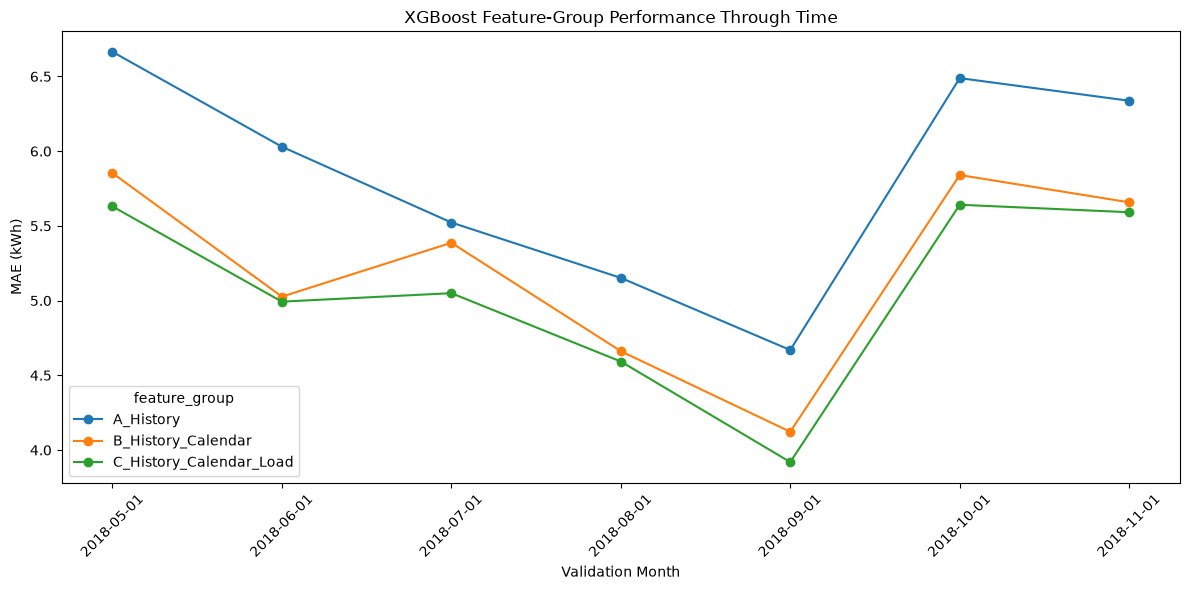

In [47]:
xgb_monthly.plot(
    figsize=(12, 6),
    marker="o"
)

plt.ylabel(
    "MAE (kWh)"
)

plt.xlabel(
    "Validation Month"
)

plt.title(
    "XGBoost Feature-Group Performance Through Time"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

In [48]:
#Compare again persistance
#we know persistance MAE from previous workbook
persistence_mae = 5.986253

In [49]:
feature_summary[
    "MAE_improvement_vs_persistence_pct"
] = (
    (
        persistence_mae
        -
        feature_summary["MAE_mean"]
    )
    /
    persistence_mae
    *
    100
)

feature_summary.sort_values(
    "MAE_mean"
)

,model,feature_group,MAE_mean,MAE_std,RMSE_mean,R2_mean,R2_std,MAE_improvement_vs_persistence_pct
5,XGBoost,C_History_Calendar_Load,5.059619,0.641519,10.429373,0.891210,0.011223,15.479360
2,Random Forest,C_History_Calendar_Load,5.088596,0.719545,10.450835,0.890917,0.012753,14.995311
1,Random Forest,B_History_Calendar,5.166736,0.710770,10.631126,0.887015,0.013529,13.689991
4,XGBoost,B_History_Calendar,5.221242,0.653151,10.672854,0.886014,0.014933,12.779455
0,Random Forest,A_History,5.704398,0.686120,11.813429,0.860078,0.018602,4.708378
3,XGBoost,A_History,5.837726,0.744840,12.095830,0.853011,0.025671,2.481136


In [50]:
#Determine the best configuration
best_configuration = (
    feature_summary
    .sort_values(
        "MAE_mean"
    )
    .iloc[0]
)

best_configuration

model                                                 XGBoost
feature_group                         C_History_Calendar_Load
MAE_mean                                             5.059619
MAE_std                                              0.641519
RMSE_mean                                           10.429373
R2_mean                                               0.89121
R2_std                                               0.011223
MAE_improvement_vs_persistence_pct                   15.47936
Name: 5, dtype: object

# Feature-Group Comparison Conclusions

A controlled feature-group ablation study was performed using the same
expanding-window validation folds and the same Random Forest and
XGBoost configurations.

Historical energy variables alone provided only modest improvement over
the 15-minute persistence benchmark.

For XGBoost:

- History only: MAE = 5.84 kWh
- History + calendar: MAE = 5.22 kWh
- History + calendar + load type: MAE = 5.06 kWh

Adding calendar information reduced MAE by approximately 10.6% relative
to historical energy features alone.

Adding load type produced a further approximately 3.1% reduction in MAE.

The complete feature group produced the strongest performance:

- XGBoost MAE: 5.06 kWh
- Random Forest MAE: 5.09 kWh

The close performance of XGBoost and Random Forest continues to justify
retaining both model families.

The results indicate that recent energy history alone does not explain
the full forecasting improvement. Calendar structure provides substantial
additional predictive information, while operating load state provides a
smaller but consistent contribution.

Use of `load_type` assumes that the operating state is known before the
forecast interval begins.

The December 2018 test period remains untouched.

In [52]:
con.close()